cell 1

In [3]:
import pandas as pd
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# LIAR dataset folder
DATA_DIR = PROJECT_ROOT / "data" / "liar"

# Dataset files
train_path = DATA_DIR / "train.tsv"
valid_path = DATA_DIR / "valid.tsv"
test_path = DATA_DIR / "test.tsv"

# LIAR column names
columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]

# Load training data
train_df = pd.read_csv(
    train_path,
    sep="\t",
    header=None,
    names=columns
)

# Load validation data
valid_df = pd.read_csv(
    valid_path,
    sep="\t",
    header=None,
    names=columns
)

# Load test data
test_df = pd.read_csv(
    test_path,
    sep="\t",
    header=None,
    names=columns
)

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10240, 14)
Validation shape: (1284, 14)
Test shape: (1267, 14)


cell 2

In [4]:
print("Training labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(valid_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Training labels:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

Validation labels:
label
false          263
mostly-true    251
half-true      248
barely-true    237
true           169
pants-fire     116
Name: count, dtype: int64

Test labels:
label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64


cell 3

In [5]:
pd.set_option("display.max_colwidth", 150)

train_df[
    ["label", "statement", "subject", "speaker", "party_affiliation"]
].head(10)

,label,statement,subject,speaker,party_affiliation
0,false,Says the Annies List political group supports third-trimester abortions on demand.,abortion,dwayne-bohac,republican
1,half-true,When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.,"energy,history,job-accomplishments",scott-surovell,democrat
2,mostly-true,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the benefit of the doubt on Iran.""",foreign-policy,barack-obama,democrat
3,false,Health care reform legislation is likely to mandate free sex change surgeries.,health-care,blog-posting,none
4,half-true,The economic turnaround started at the end of my term.,"economy,jobs",charlie-crist,democrat
5,true,The Chicago Bears have had more starting quarterbacks in the last 10 years than the total number of tenured (UW) faculty fired during the last two...,education,robin-vos,republican
6,barely-true,Jim Dunnam has not lived in the district he represents for years now.,candidates-biography,republican-party-texas,republican
7,half-true,"I'm the only person on this stage who has worked actively just last year passing, along with Russ Feingold, some of the toughest ethics reform sin...",ethics,barack-obama,democrat
8,half-true,"However, it took $19.5 million in Oregon Lottery funds for the Port of Newport to eventually land the new NOAA Marine Operations Center-Pacific.",jobs,oregon-lottery,organization
9,mostly-true,Says GOP primary opponents Glenn Grothman and Joe Leibham cast a compromise vote that cost $788 million in higher electricity costs.,"energy,message-machine-2014,voting-record",duey-stroebel,republican


cell 4

In [6]:
print("Missing values in training data:")
print(train_df.isnull().sum())

Missing values in training data:
id                         0
label                      0
statement                  0
subject                    2
speaker                    2
job_title               2898
state_info              2210
party_affiliation          2
barely_true_counts         2
false_counts               2
half_true_counts           2
mostly_true_counts         2
pants_on_fire_counts       2
context                  102
dtype: int64


cell 5

In [7]:
duplicate_count = train_df["statement"].duplicated().sum()

print("Duplicate statements in training set:", duplicate_count)

Duplicate statements in training set: 17


cell 6

In [8]:
train_df["word_count"] = (
    train_df["statement"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

print(train_df["word_count"].describe())

count    10240.000000
mean        18.010059
std          9.658572
min          2.000000
25%         12.000000
50%         17.000000
75%         22.000000
max        467.000000
Name: word_count, dtype: float64


cell 7

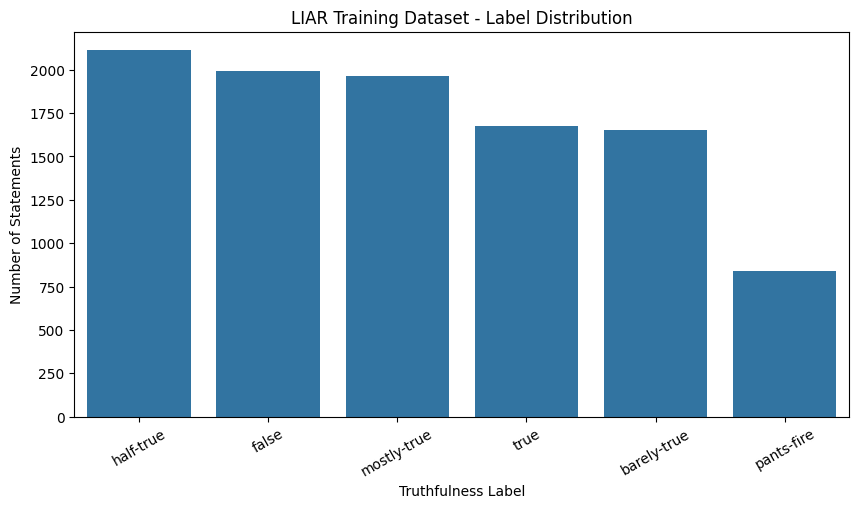

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="label",
    order=train_df["label"].value_counts().index
)

plt.title("LIAR Training Dataset - Label Distribution")
plt.xlabel("Truthfulness Label")
plt.ylabel("Number of Statements")
plt.xticks(rotation=30)

plt.show()

cell 8

In [10]:
train_statements = set(train_df["statement"].dropna())
valid_statements = set(valid_df["statement"].dropna())
test_statements = set(test_df["statement"].dropna())

print("Train ∩ Validation:", len(train_statements & valid_statements))
print("Train ∩ Test:", len(train_statements & test_statements))
print("Validation ∩ Test:", len(valid_statements & test_statements))

Train ∩ Validation: 5
Train ∩ Test: 4
Validation ∩ Test: 0


In [11]:
# Find overlapping statements between dataset splits

train_valid_overlap = train_statements & valid_statements
train_test_overlap = train_statements & test_statements

print("=== Train ↔ Validation Overlap ===")

for statement in train_valid_overlap:
    print("\n", statement)


print("\n=== Train ↔ Test Overlap ===")

for statement in train_test_overlap:
    print("\n", statement)

=== Train ↔ Validation Overlap ===

 Signs letter saying Consumer Product Safety Commission is acting without consultation or input from the company to stop the sale of Buckyballs.

 Martin Luther King Jr. was a Republican.

 Americans havent had a raise in 15 years.

 On high-speed rail.

 Social Security is a Ponzi scheme.

=== Train ↔ Test Overlap ===

 On offshore drilling.

 Says Milken Institute rated San Antonio as nations top-performing local economy.

 On a cap-and-trade plan.

 On Common Core.


In [12]:
print("=== Train / Validation Duplicate Labels ===")

for statement in train_valid_overlap:

    print("\nStatement:")
    print(statement)

    print("\nTrain label:")
    print(train_df.loc[
        train_df["statement"] == statement,
        "label"
    ].tolist())

    print("Validation label:")
    print(valid_df.loc[
        valid_df["statement"] == statement,
        "label"
    ].tolist())


print("\n=== Train / Test Duplicate Labels ===")

for statement in train_test_overlap:

    print("\nStatement:")
    print(statement)

    print("\nTrain label:")
    print(train_df.loc[
        train_df["statement"] == statement,
        "label"
    ].tolist())

    print("Test label:")
    print(test_df.loc[
        test_df["statement"] == statement,
        "label"
    ].tolist())

=== Train / Validation Duplicate Labels ===

Statement:
Signs letter saying Consumer Product Safety Commission is acting without consultation or input from the company to stop the sale of Buckyballs.

Train label:
['false']
Validation label:
['false']

Statement:
Martin Luther King Jr. was a Republican.

Train label:
['false']
Validation label:
['false']

Statement:
Americans havent had a raise in 15 years.

Train label:
['mostly-true']
Validation label:
['mostly-true']

Statement:
On high-speed rail.

Train label:
['false']
Validation label:
['false']

Statement:
Social Security is a Ponzi scheme.

Train label:
['false']
Validation label:
['false']

=== Train / Test Duplicate Labels ===

Statement:
On offshore drilling.

Train label:
['half-true']
Test label:
['half-true']

Statement:
Says Milken Institute rated San Antonio as nations top-performing local economy.

Train label:
['true']
Test label:
['true']

Statement:
On a cap-and-trade plan.

Train label:
['false', 'false']
Test lab

cell 9

In [13]:
total_records = (
    len(train_df)
    + len(valid_df)
    + len(test_df)
)

print("Training records:", len(train_df))
print("Validation records:", len(valid_df))
print("Test records:", len(test_df))
print("Total records:", total_records)

Training records: 10240
Validation records: 1284
Test records: 1267
Total records: 12791


In [14]:
# Check duplicate statements within the training dataset

duplicate_rows = train_df[
    train_df["statement"].duplicated(keep=False)
].sort_values("statement")

print("Number of duplicate rows:", len(duplicate_rows))

duplicate_rows[
    ["label", "statement", "speaker", "party_affiliation"]
]

Number of duplicate rows: 33


,label,statement,speaker,party_affiliation
4839,half-true,"During Sherrod Browns past decade as a D.C. politician, more than one out of every four jobs that has left America, left from Ohio. ... Sherrod Br...",josh-mandel,republican
1582,half-true,"During Sherrod Browns past decade as a D.C. politician, more than one out of every four jobs that has left America, left from Ohio. ... Sherrod Br...",josh-mandel,republican
1526,half-true,"Four balanced budgets in a row, with no new taxes for anyone. The best job growth in 12 years. Nearly 130,000 new private-sector jobs. Merit pay t...",chris-christie,republican
2846,mostly-true,"Four balanced budgets in a row, with no new taxes for anyone. The best job growth in 12 years. Nearly 130,000 new private-sector jobs. Merit pay t...",chris-christie,republican
848,false,"Obama says Iran is a 'tiny' country, 'doesn't pose a serious threat.'",john-mccain,republican
1846,false,"Obama says Iran is a 'tiny' country, 'doesn't pose a serious threat.'",john-mccain,republican
3256,false,On a cap-and-trade plan.,tim-pawlenty,republican
2872,false,On a cap-and-trade plan.,scott-bruun,republican
709,false,On abortion,mitt-romney,republican
1014,half-true,On abortion,charlie-crist,democrat


In [15]:
# Count how many times each duplicated statement appears

duplicate_groups = train_df[
    train_df["statement"].duplicated(keep=False)
]["statement"].value_counts()

print("Duplicate statement groups:")
print(duplicate_groups)

Duplicate statement groups:
statement
On changing the rules for filibusters on presidential nominees                                                                                                                                                                3
On abortion                                                                                                                                                                                                                   2
On support for gay marriage.                                                                                                                                                                                                  2
Obama says Iran is a 'tiny' country, 'doesn't pose a serious threat.'                                                                                                                                                         2
Four balanced budgets in a row, with no new taxes for anyone. The 